In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import average_precision_score

In [2]:
import os
print(os.getcwd())

c:\Users\bhumi\OneDrive\Documents\Credit Card Fraud Detection\notebooks


In [3]:
print(os.listdir())

['01_data_understanding.ipynb']


In [4]:
print(os.listdir("../"))

['data', 'Dockerfile', 'models', 'notebooks', 'requirements.txt', 'src', 'venv']


In [5]:
import os

print(os.listdir("../data"))

['raw']


In [6]:
import os

print(os.listdir("../data/raw"))

['creditcard.csv']


In [7]:
df = pd.read_csv("../data/raw/creditcard.csv")

In [8]:
df.shape

(284807, 31)

In [9]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [10]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [11]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(1081)

In [13]:
df.nunique()

Time      124592
V1        275663
V2        275663
V3        275663
V4        275663
V5        275663
V6        275663
V7        275663
V8        275663
V9        275663
V10       275663
V11       275663
V12       275663
V13       275663
V14       275663
V15       275663
V16       275663
V17       275663
V18       275663
V19       275663
V20       275663
V21       275663
V22       275663
V23       275663
V24       275663
V25       275663
V26       275663
V27       275663
V28       275663
Amount     32767
Class          2
dtype: int64

In [14]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [15]:
class_percentage = df["Class"].value_counts(normalize=True) * 100

print(class_percentage)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [16]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [17]:
df["Amount"].describe()


count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

In [18]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


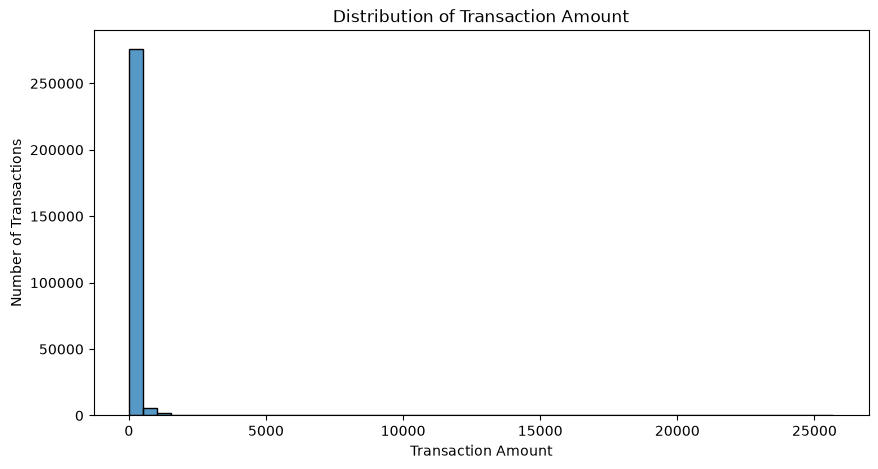

In [19]:
plt.figure(figsize=(10, 5))

sns.histplot(df["Amount"], bins=50)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")

plt.show()


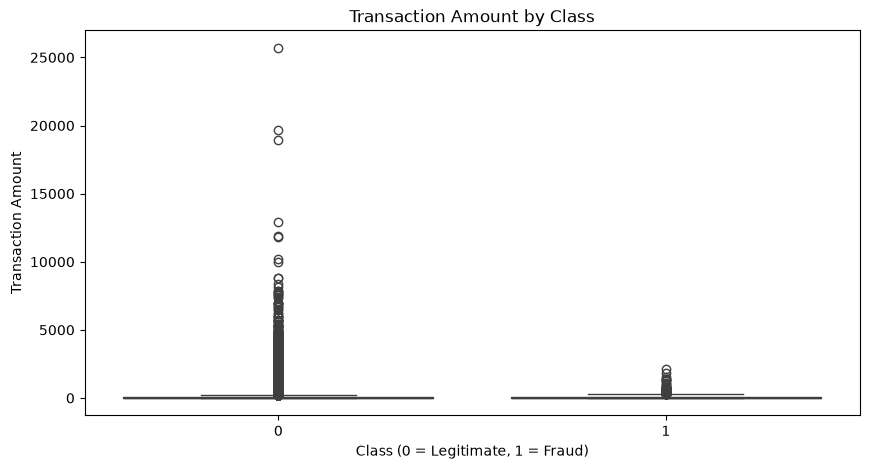

In [20]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df, x="Class", y="Amount")

plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

In [21]:
df["Time"].describe()

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

In [22]:
df.groupby("Class")["Time"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,94838.202258,47484.015786,0.0,54230.0,84711.0,139333.0,172792.0
1,492.0,80746.806911,47835.365138,406.0,41241.5,75568.5,128483.0,170348.0


In [23]:
df["Time_hours"] = df["Time"] / 3600

df["Time_hours"].describe()

count    284807.000000
mean         26.337183
std          13.191152
min           0.000000
25%          15.055972
50%          23.525556
75%          38.700139
max          47.997778
Name: Time_hours, dtype: float64

In [24]:
df[["V1", "V2", "V3", "V4", "V5", "V6", "V7", "V8", "V9", "V10"]].describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10
count,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05
mean,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,2.238554e-15
std,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00
min,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01
25%,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01
50%,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02
75%,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01
max,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01


In [25]:
df[["V11", "V12", "V13", "V14", "V15", "V16", "V17", "V18", "V19", "V20"]].describe()

,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20
count,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05
mean,1.724421e-15,-1.245415e-15,8.238900e-16,1.213481e-15,4.866699e-15,1.436219e-15,-3.768179e-16,9.707851e-16,1.036249e-15,6.418678e-16
std,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01
min,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01
25%,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01
50%,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02
75%,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01
max,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01


In [26]:
df[["V21", "V22", "V23", "V24", "V25", "V26", "V27", "V28"]].describe()

,V21,V22,V23,V24,V25,V26,V27,V28
count,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05
mean,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16
std,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01
min,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01
25%,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02
50%,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02
75%,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02
max,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01


In [27]:
feature_cols = [f"V{i}" for i in range(1, 29)]

class_means = df.groupby("Class")[feature_cols].mean().T

class_means.columns = ["Legitimate", "Fraud"]

class_means["Difference"] = (
    class_means["Fraud"] - class_means["Legitimate"]
)

class_means.sort_values("Difference", key=abs, ascending=False).head(10)

,Legitimate,Fraud,Difference
V3,0.012171,-7.033281,-7.045452
V14,0.012064,-6.971723,-6.983787
V17,0.011535,-6.665836,-6.677371
V12,0.010832,-6.259393,-6.270225
V10,0.009824,-5.676883,-5.686707
V7,0.009637,-5.568731,-5.578368
V1,0.008258,-4.771948,-4.780206
V4,-0.007860,4.542029,4.549889
V16,0.007164,-4.139946,-4.147110
V11,-0.006576,3.800173,3.806749


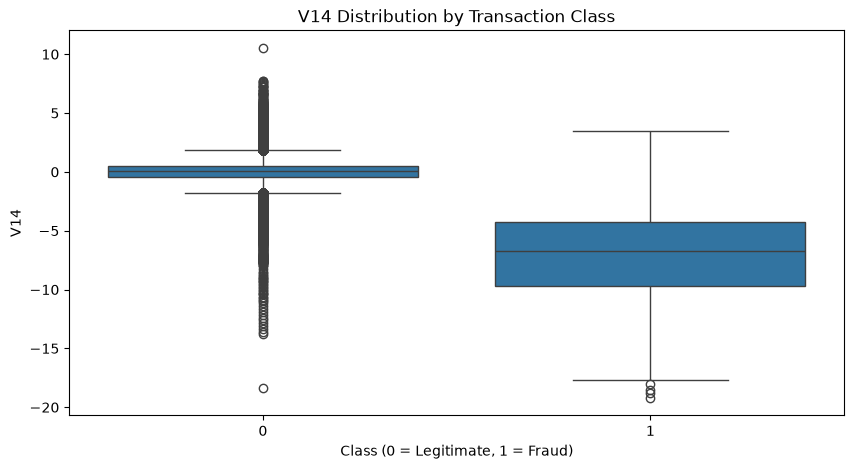

In [28]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df, x="Class", y="V14")

plt.title("V14 Distribution by Transaction Class")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("V14")

plt.show()

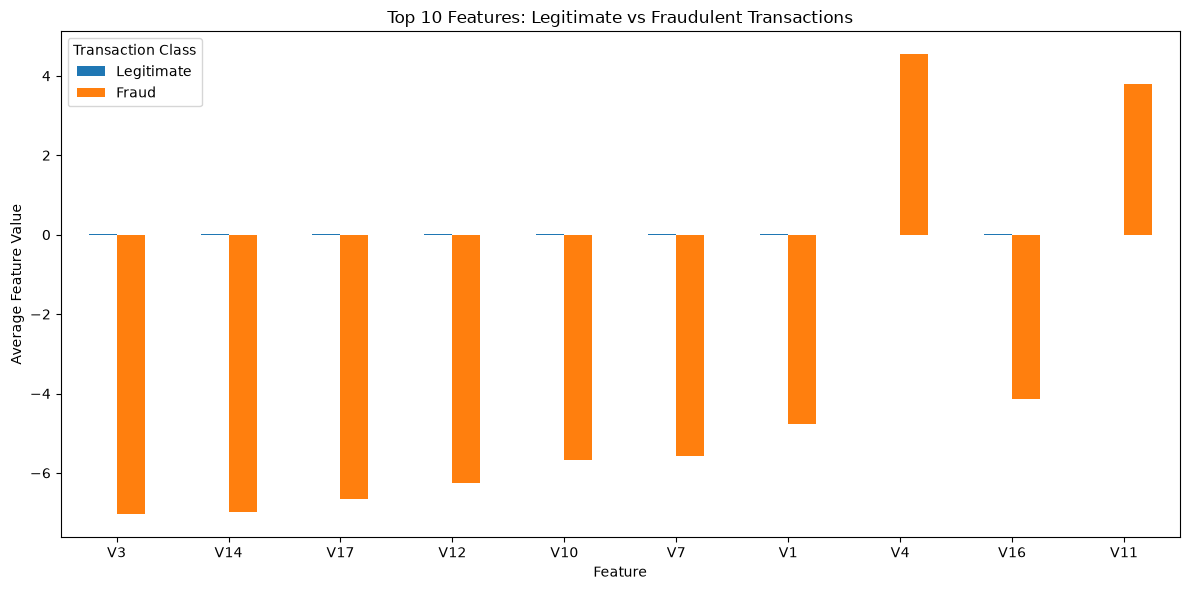

In [29]:
top_features = class_means.sort_values(
    "Difference",
    key=abs,
    ascending=False
).head(10)

top_features[["Legitimate", "Fraud"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Top 10 Features: Legitimate vs Fraudulent Transactions")
plt.xlabel("Feature")
plt.ylabel("Average Feature Value")
plt.xticks(rotation=0)
plt.legend(title="Transaction Class")
plt.tight_layout()
plt.show()

In [30]:
correlations = df.corr(numeric_only=True)["Class"].sort_values(
    key=abs,
    ascending=False
)

correlations.head(15)

Class    1.000000
V17     -0.326481
V14     -0.302544
V12     -0.260593
V10     -0.216883
V16     -0.196539
V3      -0.192961
V7      -0.187257
V11      0.154876
V4       0.133447
V18     -0.111485
V1      -0.101347
V9      -0.097733
V5      -0.094974
V2       0.091289
Name: Class, dtype: float64

In [31]:
df[["Time", "Time_hours", "Amount", "Class"]].corr()["Class"].sort_values(
    key=abs,
    ascending=False
)

Class         1.000000
Time_hours   -0.012323
Time         -0.012323
Amount        0.005632
Name: Class, dtype: float64

In [32]:
duplicate_rows = df[df.duplicated(keep=False)]

duplicate_rows["Class"].value_counts()

Class
0    1822
1      32
Name: count, dtype: int64

In [33]:
duplicate_counts = (
    df.value_counts()
      .reset_index(name="Count")
)

duplicate_counts[duplicate_counts["Count"] > 1].head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,Time_hours,Count
0,163152.0,-1.196037,1.585949,2.883976,3.378471,1.511706,3.717077,0.585362,-0.156001,0.122648,...,-0.355170,-0.869790,-0.133198,0.327804,-0.035702,-0.858197,7.56,0,45.320000,18
1,163152.0,-1.203617,1.574009,2.889277,3.381404,1.538663,3.698747,0.560211,-0.150911,0.124136,...,-0.357329,-0.870174,-0.134166,0.327019,-0.042648,-0.855262,1.51,0,45.320000,18
2,43153.0,-2.086016,2.203265,1.654339,2.941050,-1.683045,0.529728,-1.352162,1.793449,-0.723686,...,-0.035345,0.370201,0.157378,0.440341,0.210230,0.090558,0.76,0,11.986944,9
3,170731.0,2.033492,0.766969,-2.107555,3.631952,1.348594,-0.499907,0.945159,-0.286392,-1.370581,...,-0.102644,0.580535,0.643637,0.347240,-0.116618,-0.078601,0.76,0,47.425278,9
4,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1,18.946389,6
5,64947.0,-6.370459,3.306401,1.724991,-1.589581,0.174936,0.232403,2.967884,-3.421005,7.937413,...,-0.364322,0.480224,0.154904,-0.535302,-4.787907,-3.696616,12.33,0,18.040833,5
6,64947.0,-6.378440,3.293830,1.730572,-1.586493,0.203319,0.213103,2.941403,-3.415646,7.938980,...,-0.366595,0.479819,0.153885,-0.536129,-4.795220,-3.693525,5.96,0,18.040833,5
7,64947.0,-6.327870,3.373477,1.695209,-1.606061,0.023487,0.335386,3.109186,-3.449599,7.929051,...,-0.352190,0.482383,0.160342,-0.530889,-4.748881,-3.713108,46.32,0,18.040833,5
8,64947.0,-6.342969,3.349697,1.705767,-1.600219,0.077178,0.298877,3.059092,-3.439462,7.932015,...,-0.356491,0.481618,0.158414,-0.532454,-4.762716,-3.707261,34.27,0,18.040833,5
9,64947.0,-6.373391,3.301783,1.727041,-1.588447,0.185362,0.225313,2.958156,-3.419036,7.937988,...,-0.365157,0.480075,0.154530,-0.535606,-4.790593,-3.695480,9.99,0,18.040833,5


In [34]:
exact_duplicates = df[df.duplicated(keep=False)]

exact_duplicates.groupby(["Class"]).size()

Class
0    1822
1      32
dtype: int64

In [35]:
duplicate_label_check = (
    df.groupby(list(df.columns))
      .agg(
          occurrences=("Class", "size"),
          unique_labels=("Class", "nunique")
      )
      .reset_index()
)

duplicate_label_check[
    (duplicate_label_check["occurrences"] > 1) &
    (duplicate_label_check["unique_labels"] > 1)
]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V24,V25,V26,V27,V28,Amount,Class,Time_hours,occurrences,unique_labels


In [36]:
numeric_cols = df.select_dtypes(include=np.number).columns

validation_check = pd.DataFrame({
    "Missing_Values": df[numeric_cols].isnull().sum(),
    "Infinite_Values": np.isinf(df[numeric_cols]).sum()
})

validation_check

,Missing_Values,Infinite_Values
Time,0,0
V1,0,0
V2,0,0
V3,0,0
V4,0,0
V5,0,0
V6,0,0
V7,0,0
V8,0,0
V9,0,0


In [37]:
amount_bins = pd.qcut(
    df["Amount"],
    q=10,
    duplicates="drop"
)

fraud_by_amount = (
    df.groupby(amount_bins, observed=True)["Class"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

fraud_by_amount["Fraud_Rate_%"] = fraud_by_amount["mean"] * 100

fraud_by_amount

,Amount,count,sum,mean,Fraud_Rate_%
0,"(-0.001, 1.0]",30492,181,0.005936,0.593598
1,"(1.0, 3.57]",26473,27,0.001020,0.101991
2,"(3.57, 8.91]",28559,36,0.001261,0.126055
3,"(8.91, 13.0]",28405,13,0.000458,0.045767
4,"(13.0, 22.0]",28714,14,0.000488,0.048757
5,"(22.0, 37.0]",28375,17,0.000599,0.059912
6,"(37.0, 59.8]",28366,24,0.000846,0.084608
7,"(59.8, 100.0]",28915,50,0.001729,0.172921
8,"(100.0, 203.0]",28050,45,0.001604,0.160428
9,"(203.0, 25691.16]",28458,85,0.002987,0.298686


In [38]:
time_bins = pd.qcut(
    df["Time"],
    q=10,
    duplicates="drop"
)

fraud_by_time = (
    df.groupby(time_bins, observed=True)["Class"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

fraud_by_time["Fraud_Rate_%"] = fraud_by_time["mean"] * 100

fraud_by_time

,Time,count,sum,mean,Fraud_Rate_%
0,"(-0.001, 35027.0]",28482,93,0.003265,0.326522
1,"(35027.0, 47694.2]",28480,64,0.002247,0.224719
2,"(47694.2, 60776.0]",28483,47,0.001650,0.165011
3,"(60776.0, 73261.4]",28478,37,0.001299,0.129925
4,"(73261.4, 84692.0]",28481,28,0.000983,0.098311
5,"(84692.0, 120396.0]",28484,91,0.003195,0.319478
6,"(120396.0, 132929.0]",28480,24,0.000843,0.084270
7,"(132929.0, 145247.8]",28477,33,0.001159,0.115883
8,"(145247.8, 157640.4]",28481,53,0.001861,0.186089
9,"(157640.4, 172792.0]",28481,22,0.000772,0.077244


In [39]:
fraud_by_time[["Time", "count", "sum", "Fraud_Rate_%"]]

,Time,count,sum,Fraud_Rate_%
0,"(-0.001, 35027.0]",28482,93,0.326522
1,"(35027.0, 47694.2]",28480,64,0.224719
2,"(47694.2, 60776.0]",28483,47,0.165011
3,"(60776.0, 73261.4]",28478,37,0.129925
4,"(73261.4, 84692.0]",28481,28,0.098311
5,"(84692.0, 120396.0]",28484,91,0.319478
6,"(120396.0, 132929.0]",28480,24,0.084270
7,"(132929.0, 145247.8]",28477,33,0.115883
8,"(145247.8, 157640.4]",28481,53,0.186089
9,"(157640.4, 172792.0]",28481,22,0.077244


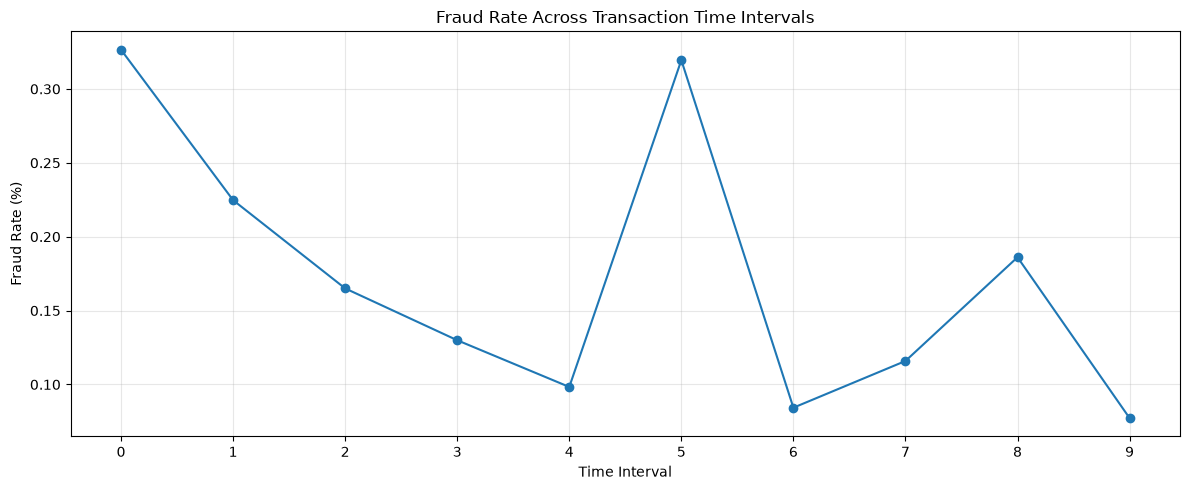

In [40]:
plt.figure(figsize=(12, 5))

plt.plot(
    range(len(fraud_by_time)),
    fraud_by_time["Fraud_Rate_%"],
    marker="o"
)

plt.title("Fraud Rate Across Transaction Time Intervals")
plt.xlabel("Time Interval")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(len(fraud_by_time)))

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

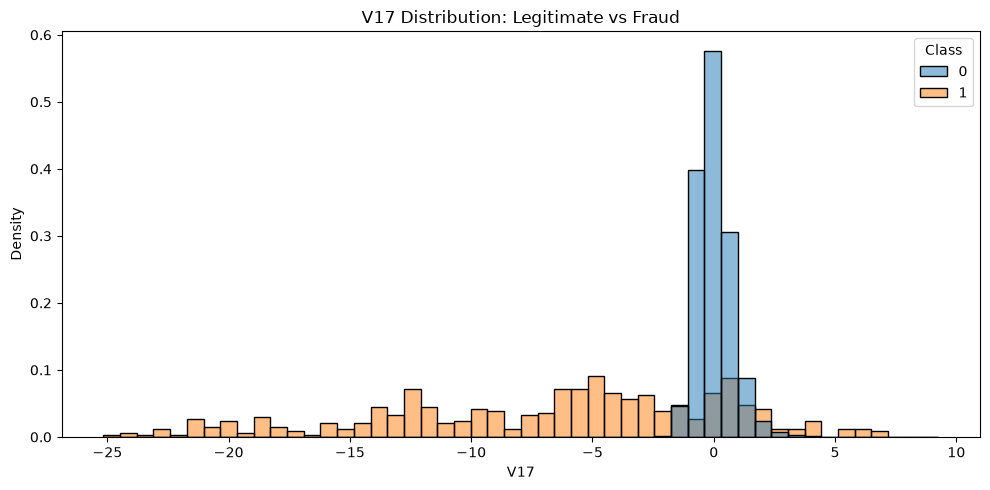

In [41]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="V17",
    hue="Class",
    bins=50,
    stat="density",
    common_norm=False
)

plt.title("V17 Distribution: Legitimate vs Fraud")
plt.xlabel("V17")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

In [42]:
class_summary = (
    df["Class"]
    .value_counts()
    .sort_index()
    .to_frame("Transaction_Count")
)

class_summary["Percentage"] = (
    class_summary["Transaction_Count"]
    / len(df)
    * 100
)

class_summary.index = ["Legitimate", "Fraud"]

class_summary

,Transaction_Count,Percentage
Legitimate,284315,99.827251
Fraud,492,0.172749


In [43]:
X = df.drop(columns=["Class"])
y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (284807, 31)
y shape: (284807,)


In [44]:
(df["Time"] / 3600 == df["Time_hours"]).all()

np.True_

In [45]:
X = df.drop(columns=["Class", "Time_hours"])
y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (284807, 30)
y shape: (284807,)


In [46]:
print("Total rows:", len(df))
print("Unique rows:", df.drop_duplicates().shape[0])
print("Duplicate occurrences:", df.duplicated().sum())

Total rows: 284807
Unique rows: 283726
Duplicate occurrences: 1081


In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (227845, 30)
X_test : (56962, 30)
y_train: (227845,)
y_test : (56962,)


In [48]:
train_duplicates = X_train.merge(
    X_test,
    how="inner"
)

print("Duplicate feature rows across train and test:", len(train_duplicates))

Duplicate feature rows across train and test: 600


In [49]:
overlap_rows = X_train.merge(
    X_test,
    how="inner"
)

overlap_with_labels = overlap_rows.merge(
    df[["Time", "V1", "V2", "V3", "V4", "V5", "V6", "V7", "V8",
        "V9", "V10", "V11", "V12", "V13", "V14", "V15", "V16",
        "V17", "V18", "V19", "V20", "V21", "V22", "V23", "V24",
        "V25", "V26", "V27", "V28", "Amount", "Class"]],
    on=list(X.columns),
    how="left"
)

overlap_with_labels["Class"].value_counts()

Class
0    3164
1      70
Name: count, dtype: int64

In [50]:
train_unique = X_train.drop_duplicates()
test_unique = X_test.drop_duplicates()

overlap_unique = train_unique.merge(
    test_unique,
    how="inner"
)

print("Unique transactions overlapping train/test:", len(overlap_unique))

Unique transactions overlapping train/test: 293


In [51]:
df_unique = df.drop_duplicates().copy()

print("Original rows:", len(df))
print("Unique rows:", len(df_unique))
print("Rows removed:", len(df) - len(df_unique))

Original rows: 284807
Unique rows: 283726
Rows removed: 1081


In [52]:
X_unique = df_unique.drop(columns=["Class", "Time_hours"])
y_unique = df_unique["Class"]

print("X_unique shape:", X_unique.shape)
print("y_unique shape:", y_unique.shape)

X_unique shape: (283726, 30)
y_unique shape: (283726,)


In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X_unique,
    y_unique,
    test_size=0.20,
    random_state=42,
    stratify=y_unique
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (226980, 30)
X_test : (56746, 30)
y_train: (226980,)
y_test : (56746,)


In [54]:
print("Overall fraud rate:", y_unique.mean() * 100)
print("Training fraud rate:", y_train.mean() * 100)
print("Testing fraud rate :", y_test.mean() * 100)

Overall fraud rate: 0.1667101358352777
Training fraud rate: 0.16653449643140364
Testing fraud rate : 0.16741268107003138


In [55]:
train_unique_check = X_train.drop_duplicates()
test_unique_check = X_test.drop_duplicates()

overlap_check = train_unique_check.merge(
    test_unique_check,
    how="inner"
)

print("Identical transactions across train/test:", len(overlap_check))


Identical transactions across train/test: 0


In [56]:
print("Training set:")
print(y_train.value_counts())

print("\nTesting set:")
print(y_test.value_counts())

Training set:
Class
0    226602
1       378
Name: count, dtype: int64

Testing set:
Class
0    56651
1       95
Name: count, dtype: int64


In [57]:
feature_ranges = pd.DataFrame({
    "Min": X_train.min(),
    "Max": X_train.max(),
    "Mean": X_train.mean(),
    "Std": X_train.std()
})

feature_ranges

,Min,Max,Mean,Std
Time,0.000000,172792.000000,94900.224390,47488.214282
V1,-56.407510,2.454930,0.005027,1.947293
V2,-72.715728,22.057729,-0.005549,1.649617
V3,-33.680984,9.382558,0.002131,1.507270
V4,-5.683171,16.875344,-0.002025,1.416960
V5,-32.092129,34.801666,0.004941,1.359643
V6,-26.160506,21.393069,-0.001961,1.323401
V7,-43.557242,34.303177,0.001480,1.200181
V8,-73.216718,20.007208,-0.000215,1.169342
V9,-13.434066,15.594995,-0.002883,1.094055


In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)

X_train_scaled shape: (226980, 30)
X_test_scaled shape : (56746, 30)


In [59]:
scaled_check = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

scaled_check[["Time", "Amount", "V1", "V14", "V17"]].describe().loc[
    ["mean", "std"]
]

,Time,Amount,V1,V14,V17
mean,-1.522636e-16,7.487965e-17,6.699099e-18,-1.940860e-17,-2.504336e-19
std,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00


In [60]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(X_train_scaled, y_train)

dummy_pred = dummy_model.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, dummy_pred))
print("Precision:", precision_score(y_test, dummy_pred, zero_division=0))
print("Recall   :", recall_score(y_test, dummy_pred, zero_division=0))
print("F1-score :", f1_score(y_test, dummy_pred, zero_division=0))

Accuracy : 0.9983258731892997
Precision: 0.0
Recall   : 0.0
F1-score : 0.0


In [61]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

logistic_pred = logistic_model.predict(X_test_scaled)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [62]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, logistic_pred))
print("Precision:", precision_score(y_test, logistic_pred, zero_division=0))
print("Recall   :", recall_score(y_test, logistic_pred, zero_division=0))
print("F1-score :", f1_score(y_test, logistic_pred, zero_division=0))

Accuracy : 0.9753110351390406
Precision: 0.05638586956521739
Recall   : 0.8736842105263158
F1-score : 0.10593490746649649


In [63]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, logistic_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[55262  1389]
 [   12    83]]


In [64]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, logistic_pred).ravel()

false_positive_rate = fp / (fp + tn)

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)
print("False Positive Rate:", false_positive_rate)

True Negatives : 55262
False Positives: 1389
False Negatives: 12
True Positives : 83
False Positive Rate: 0.024518543361988315


In [65]:
logistic_probabilities = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("First 10 fraud probabilities:")
print(logistic_probabilities[:10])

print("\nMinimum probability:", logistic_probabilities.min())
print("Maximum probability:", logistic_probabilities.max())
print("Average probability :", logistic_probabilities.mean())

First 10 fraud probabilities:
[0.02162645 0.02007152 0.01024023 0.01572015 0.21923533 0.06080725
 0.02212544 0.03847994 0.08682055 0.00180108]

Minimum probability: 2.032001531855443e-26
Maximum probability: 1.0
Average probability : 0.07308044466809856


In [66]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

for threshold in np.arange(0.1, 1.0, 0.1):
    threshold_pred = (logistic_probabilities >= threshold).astype(int)

    threshold_results.append({
        "Threshold": round(threshold, 1),
        "Precision": precision_score(
            y_test,
            threshold_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            threshold_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            threshold_pred,
            zero_division=0
        )
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df

,Threshold,Precision,Recall,F1
0,0.1,0.008682,0.936842,0.017205
1,0.2,0.016721,0.915789,0.032843
2,0.3,0.026757,0.873684,0.051924
3,0.4,0.039981,0.873684,0.076462
4,0.5,0.056386,0.873684,0.105935
5,0.6,0.078822,0.873684,0.144599
6,0.7,0.115760,0.873684,0.204433
7,0.8,0.160321,0.842105,0.269360
8,0.9,0.262458,0.831579,0.398990


In [67]:
best_threshold_row = threshold_results_df.loc[
    threshold_results_df["F1"].idxmax()
]

print("Best threshold:", best_threshold_row["Threshold"])
print("Precision     :", best_threshold_row["Precision"])
print("Recall        :", best_threshold_row["Recall"])
print("F1-score      :", best_threshold_row["F1"])

Best threshold: 0.9
Precision     : 0.26245847176079734
Recall        : 0.8315789473684211
F1-score      : 0.398989898989899


In [68]:
fine_threshold_results = []

for threshold in np.arange(0.50, 1.00, 0.01):
    threshold_pred = (
        logistic_probabilities >= threshold
    ).astype(int)

    fine_threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(
            y_test,
            threshold_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            threshold_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            threshold_pred,
            zero_division=0
        )
    })

fine_threshold_results_df = pd.DataFrame(
    fine_threshold_results
)

best_fine_threshold = fine_threshold_results_df.loc[
    fine_threshold_results_df["F1"].idxmax()
]

print(best_fine_threshold)

Threshold    0.990000
Precision    0.657895
Recall       0.789474
F1           0.717703
Name: 49, dtype: float64


In [69]:
best_threshold = 0.99

best_threshold_pred = (
    logistic_probabilities >= best_threshold
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    best_threshold_pred
).ravel()

print("Threshold:", best_threshold)
print()
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

Threshold: 0.99

True Negatives : 56612
False Positives: 39
False Negatives: 20
True Positives : 75


In [70]:
from sklearn.model_selection import train_test_split

X_train_model, X_val, y_train_model, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training set:", X_train_model.shape)
print("Validation set:", X_val.shape)
print("Test set     :", X_test.shape)

print("\nFraud counts:")
print("Training   :", y_train_model.sum())
print("Validation :", y_val.sum())
print("Test       :", y_test.sum())

Training set: (181584, 30)
Validation set: (45396, 30)
Test set     : (56746, 30)

Fraud counts:
Training   : 302
Validation : 76
Test       : 95


In [71]:
from sklearn.preprocessing import StandardScaler

model_scaler = StandardScaler()

X_train_model_scaled = model_scaler.fit_transform(
    X_train_model
)

X_val_scaled = model_scaler.transform(
    X_val
)

X_test_final_scaled = model_scaler.transform(
    X_test
)

print("Training scaled :", X_train_model_scaled.shape)
print("Validation scaled:", X_val_scaled.shape)
print("Test scaled     :", X_test_final_scaled.shape)

Training scaled : (181584, 30)
Validation scaled: (45396, 30)
Test scaled     : (56746, 30)


In [72]:
logistic_model_v2 = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

logistic_model_v2.fit(
    X_train_model_scaled,
    y_train_model
)

print("Logistic Regression v2 trained successfully.")

Logistic Regression v2 trained successfully.


In [73]:
val_probabilities = logistic_model_v2.predict_proba(
    X_val_scaled
)[:, 1]

print("First 10 validation fraud probabilities:")
print(val_probabilities[:10])

print("\nMinimum probability:", val_probabilities.min())
print("Maximum probability:", val_probabilities.max())
print("Average probability :", val_probabilities.mean())

First 10 validation fraud probabilities:
[0.00318895 0.01515062 0.01138963 0.01089404 0.00532812 0.00363928
 0.00350218 0.01782478 0.00113194 0.14385666]

Minimum probability: 3.52124971981582e-32
Maximum probability: 1.0
Average probability : 0.06933641970095361


In [74]:
validation_threshold_results = []

for threshold in np.arange(0.50, 1.00, 0.01):
    threshold_pred = (
        val_probabilities >= threshold
    ).astype(int)

    validation_threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(
            y_val,
            threshold_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_val,
            threshold_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_val,
            threshold_pred,
            zero_division=0
        )
    })

validation_threshold_results_df = pd.DataFrame(
    validation_threshold_results
)

best_validation_threshold = validation_threshold_results_df.loc[
    validation_threshold_results_df["F1"].idxmax()
]

print(best_validation_threshold)

Threshold    0.990000
Precision    0.575221
Recall       0.855263
F1           0.687831
Name: 49, dtype: float64


In [75]:
# Lock the threshold selected using validation data
final_threshold = 0.99

# Get fraud probabilities for the untouched test set
test_probabilities = logistic_model_v2.predict_proba(
    X_test_final_scaled
)[:, 1]

# Convert probabilities into final predictions
test_predictions = (
    test_probabilities >= final_threshold
).astype(int)

print("Final threshold:", final_threshold)
print("Test predictions generated successfully.")

Final threshold: 0.99
Test predictions generated successfully.


In [76]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

final_accuracy = accuracy_score(
    y_test,
    test_predictions
)

final_precision = precision_score(
    y_test,
    test_predictions,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    test_predictions,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    test_predictions,
    zero_division=0
)

print("FINAL TEST RESULTS")
print("------------------")
print("Threshold :", final_threshold)
print("Accuracy  :", final_accuracy)
print("Precision :", final_precision)
print("Recall    :", final_recall)
print("F1-score  :", final_f1)

FINAL TEST RESULTS
------------------
Threshold : 0.99
Accuracy  : 0.9988369224262503
Precision : 0.6198347107438017
Recall    : 0.7894736842105263
F1-score  : 0.6944444444444444


In [77]:
from sklearn.metrics import confusion_matrix

final_cm = confusion_matrix(
    y_test,
    test_predictions
)

print("Final Confusion Matrix:")
print(final_cm)

tn, fp, fn, tp = final_cm.ravel()

print("\nDetailed results:")
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

Final Confusion Matrix:
[[56605    46]
 [   20    75]]

Detailed results:
True Negatives : 56605
False Positives: 46
False Negatives: 20
True Positives : 75


In [78]:
false_positive_rate = fp / (fp + tn)

print("False Positive Rate:", false_positive_rate)
print("False Positive Rate (%):", false_positive_rate * 100)

False Positive Rate: 0.0008119891970132919
False Positive Rate (%): 0.0811989197013292


In [79]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score
)

pr_auc = average_precision_score(
    y_test,
    test_probabilities
)

roc_auc = roc_auc_score(
    y_test,
    test_probabilities
)

print("PR-AUC :", pr_auc)
print("ROC-AUC:", roc_auc)

PR-AUC : 0.6870645749940067
ROC-AUC: 0.9616843294446421


In [80]:
logistic_results = {
    "Model": "Logistic Regression",
    "Threshold": final_threshold,
    "Accuracy": final_accuracy,
    "Precision": final_precision,
    "Recall": final_recall,
    "F1": final_f1,
    "PR-AUC": pr_auc,
    "ROC-AUC": roc_auc,
    "False Positive Rate": false_positive_rate
}

model_comparison = pd.DataFrame([logistic_results])

model_comparison

,Model,Threshold,Accuracy,Precision,Recall,F1,PR-AUC,ROC-AUC,False Positive Rate
0,Logistic Regression,0.99,0.998837,0.619835,0.789474,0.694444,0.687065,0.961684,0.000812


In [81]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_model,
    y_train_model
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [82]:
rf_val_probabilities = random_forest_model.predict_proba(
    X_val
)[:, 1]

print("First 10 validation fraud probabilities:")
print(rf_val_probabilities[:10])

print("\nMinimum probability:", rf_val_probabilities.min())
print("Maximum probability:", rf_val_probabilities.max())
print("Average probability :", rf_val_probabilities.mean())

First 10 validation fraud probabilities:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Minimum probability: 0.0
Maximum probability: 1.0
Average probability : 0.0020211031808969955


In [83]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.01):

    val_predictions = (
        rf_val_probabilities >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        val_predictions,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        val_predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        val_predictions,
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df.sort_values(
    "f1",
    ascending=False
).head(10)

,threshold,precision,recall,f1
29,0.39,0.955882,0.855263,0.902778
41,0.51,0.955882,0.855263,0.902778
34,0.44,0.955882,0.855263,0.902778
35,0.45,0.955882,0.855263,0.902778
33,0.43,0.955882,0.855263,0.902778
37,0.47,0.955882,0.855263,0.902778
38,0.48,0.955882,0.855263,0.902778
39,0.49,0.955882,0.855263,0.902778
40,0.50,0.955882,0.855263,0.902778
32,0.42,0.955882,0.855263,0.902778


In [84]:
rf_validation_threshold_results = []

for threshold in np.arange(0.01, 1.00, 0.01):
    threshold_pred = (
        rf_val_probabilities >= threshold
    ).astype(int)

    rf_validation_threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(
            y_val,
            threshold_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_val,
            threshold_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_val,
            threshold_pred,
            zero_division=0
        )
    })

rf_validation_threshold_results_df = pd.DataFrame(
    rf_validation_threshold_results
)

best_rf_threshold = rf_validation_threshold_results_df.loc[
    rf_validation_threshold_results_df["F1"].idxmax()
]

print(best_rf_threshold)

Threshold    0.390000
Precision    0.955882
Recall       0.855263
F1           0.902778
Name: 38, dtype: float64


In [115]:
# Final threshold selected using validation-set performance.
# A threshold of 0.39 achieved the highest validation F1-score
# among the tested thresholds.
final_rf_threshold = 0.39

# Get fraud probabilities for the untouched test set
rf_test_probabilities = random_forest_model.predict_proba(
    X_test
)[:, 1]

# Convert probabilities into final predictions
rf_test_predictions = (
    rf_test_probabilities >= final_rf_threshold
).astype(int)

print("Final Random Forest threshold:", final_rf_threshold)
print("Random Forest test predictions generated successfully.")


Final Random Forest threshold: 0.39
Random Forest test predictions generated successfully.


In [86]:
rf_accuracy = accuracy_score(
    y_test,
    rf_test_predictions
)

rf_precision = precision_score(
    y_test,
    rf_test_predictions,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_test_predictions,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_test_predictions,
    zero_division=0
)

print("FINAL RANDOM FOREST TEST RESULTS")
print("--------------------------------")
print("Threshold :", final_rf_threshold)
print("Accuracy  :", rf_accuracy)
print("Precision :", rf_precision)
print("Recall    :", rf_recall)
print("F1-score  :", rf_f1)

FINAL RANDOM FOREST TEST RESULTS
--------------------------------
Threshold : 0.39
Accuracy  : 0.9994713283755683
Precision : 0.922077922077922
Recall    : 0.7473684210526316
F1-score  : 0.8255813953488372


In [87]:
rf_cm = confusion_matrix(
    y_test,
    rf_test_predictions
)

print("Random Forest Confusion Matrix:")
print(rf_cm)

rf_tn, rf_fp, rf_fn, rf_tp = rf_cm.ravel()

print("\nDetailed results:")
print("True Negatives :", rf_tn)
print("False Positives:", rf_fp)
print("False Negatives:", rf_fn)
print("True Positives :", rf_tp)

Random Forest Confusion Matrix:
[[56645     6]
 [   24    71]]

Detailed results:
True Negatives : 56645
False Positives: 6
False Negatives: 24
True Positives : 71


In [88]:
rf_false_positive_rate = rf_fp / (
    rf_fp + rf_tn
)

print("Random Forest False Positive Rate:", rf_false_positive_rate)
print(
    "Random Forest False Positive Rate (%):",
    rf_false_positive_rate * 100
)

Random Forest False Positive Rate: 0.00010591163439303807
Random Forest False Positive Rate (%): 0.010591163439303808


In [89]:
rf_pr_auc = average_precision_score(
    y_test,
    rf_test_probabilities
)

rf_roc_auc = roc_auc_score(
    y_test,
    rf_test_probabilities
)

print("Random Forest PR-AUC :", rf_pr_auc)
print("Random Forest ROC-AUC:", rf_roc_auc)

Random Forest PR-AUC : 0.8144955293168471
Random Forest ROC-AUC: 0.9583955873868535


In [90]:
rf_results = {
    "Model": "Random Forest",
    "Threshold": final_rf_threshold,
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1": rf_f1,
    "PR-AUC": rf_pr_auc,
    "ROC-AUC": rf_roc_auc,
    "False Positive Rate": rf_false_positive_rate
}

model_comparison = pd.concat(
    [
        model_comparison,
        pd.DataFrame([rf_results])
    ],
    ignore_index=True
)

model_comparison

,Model,Threshold,Accuracy,Precision,Recall,F1,PR-AUC,ROC-AUC,False Positive Rate
0,Logistic Regression,0.99,0.998837,0.619835,0.789474,0.694444,0.687065,0.961684,0.000812
1,Random Forest,0.39,0.999471,0.922078,0.747368,0.825581,0.814496,0.958396,0.000106


In [91]:
comparison_counts = pd.DataFrame({
    "Metric": [
        "Actual Fraud",
        "Fraud Detected (TP)",
        "Fraud Missed (FN)",
        "False Alarms (FP)"
    ],
    "Logistic Regression": [
        tp + fn,
        tp,
        fn,
        fp
    ],
    "Random Forest": [
        rf_tp + rf_fn,
        rf_tp,
        rf_fn,
        rf_fp
    ]
})

comparison_counts

,Metric,Logistic Regression,Random Forest
0,Actual Fraud,95,95
1,Fraud Detected (TP),75,71
2,Fraud Missed (FN),20,24
3,False Alarms (FP),46,6


In [92]:
feature_importance = pd.DataFrame({
    "Feature": X_train_model.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

feature_importance.head(15)

,Feature,Importance
0,V14,0.193621
1,V10,0.118034
2,V4,0.112133
3,V12,0.101351
4,V17,0.096144
5,V3,0.064456
6,V16,0.051135
7,V11,0.041966
8,V2,0.029335
9,V21,0.018780


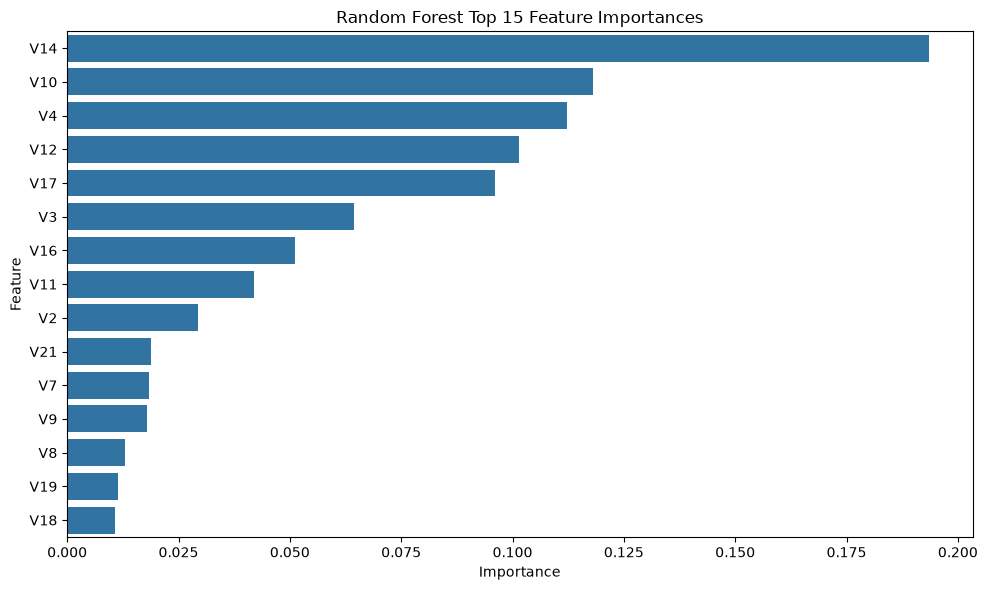

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [94]:
from sklearn.inspection import permutation_importance

permutation_result = permutation_importance(
    random_forest_model,
    X_val,
    y_val,
    scoring="average_precision",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

permutation_importance_df = pd.DataFrame({
    "Feature": X_val.columns,
    "Importance_Mean": permutation_result.importances_mean,
    "Importance_STD": permutation_result.importances_std
})

permutation_importance_df = permutation_importance_df.sort_values(
    "Importance_Mean",
    ascending=False
).reset_index(drop=True)

permutation_importance_df.head(15)

,Feature,Importance_Mean,Importance_STD
0,V4,0.035988,0.007704
1,V12,0.029563,0.017047
2,V14,0.024387,0.012432
3,V3,0.017541,0.003792
4,V11,0.015933,0.004515
5,V10,0.011579,0.002579
6,V16,0.009337,0.005140
7,V26,0.006079,0.004927
8,V9,0.005304,0.002009
9,V18,0.003310,0.001345


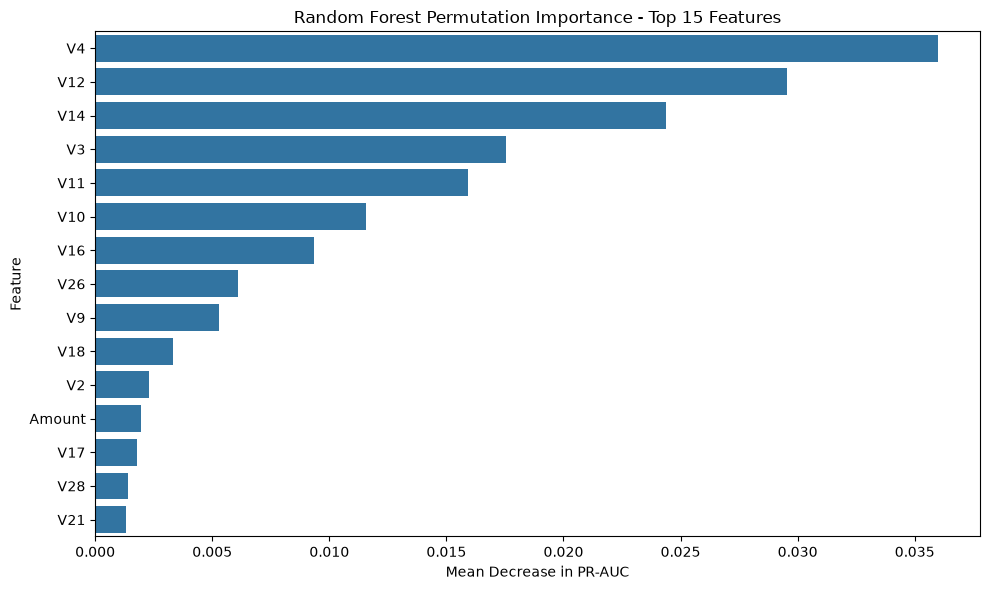

In [95]:
top_permutation_features = permutation_importance_df.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_permutation_features,
    x="Importance_Mean",
    y="Feature"
)

plt.title("Random Forest Permutation Importance - Top 15 Features")
plt.xlabel("Mean Decrease in PR-AUC")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

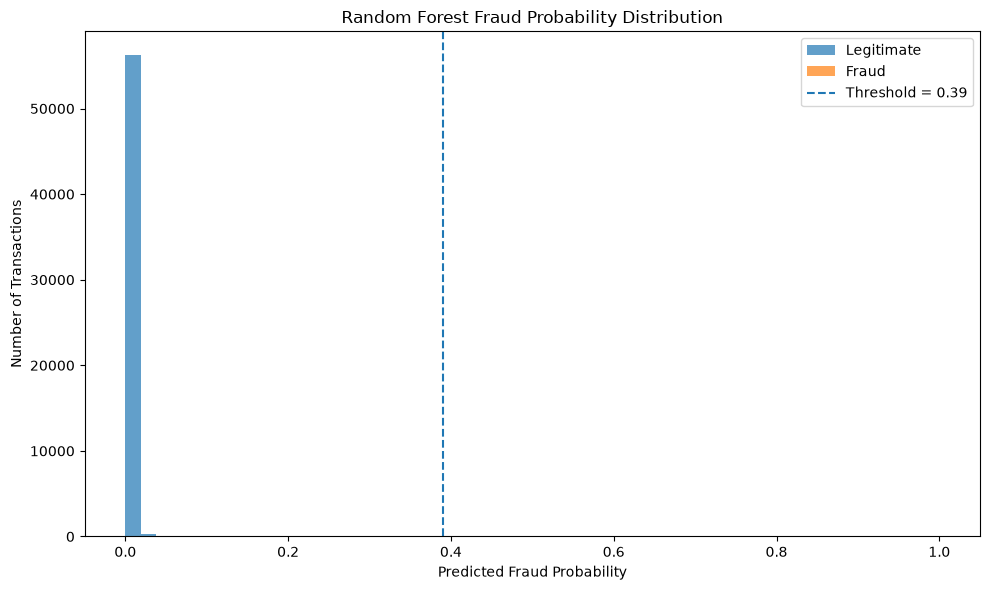

In [96]:
plt.figure(figsize=(10, 6))

plt.hist(
    rf_test_probabilities[y_test == 0],
    bins=50,
    alpha=0.7,
    label="Legitimate"
)

plt.hist(
    rf_test_probabilities[y_test == 1],
    bins=50,
    alpha=0.7,
    label="Fraud"
)

plt.axvline(
    final_rf_threshold,
    linestyle="--",
    label=f"Threshold = {final_rf_threshold}"
)

plt.title("Random Forest Fraud Probability Distribution")
plt.xlabel("Predicted Fraud Probability")
plt.ylabel("Number of Transactions")
plt.legend()

plt.tight_layout()
plt.show()

In [97]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    rf_test_predictions
).ravel()

print("Business Impact Summary")
print("-----------------------")
print(f"Total transactions tested : {len(y_test):,}")
print(f"Actual fraud transactions  : {tp + fn:,}")
print(f"Fraud detected             : {tp:,}")
print(f"Fraud missed               : {fn:,}")
print(f"Legitimate transactions    : {tn + fp:,}")
print(f"False fraud alerts         : {fp:,}")
print()
print(f"Fraud detection rate       : {tp / (tp + fn):.2%}")
print(f"False alert rate           : {fp / (tn + fp):.4%}")

Business Impact Summary
-----------------------
Total transactions tested : 56,746
Actual fraud transactions  : 95
Fraud detected             : 71
Fraud missed               : 24
Legitimate transactions    : 56,651
False fraud alerts         : 6

Fraud detection rate       : 74.74%
False alert rate           : 0.0106%


In [98]:
cost_per_missed_fraud = 5000
cost_per_false_alert = 100

cost_of_missed_fraud = fn * cost_per_missed_fraud
cost_of_false_alerts = fp * cost_per_false_alert

total_cost = cost_of_missed_fraud + cost_of_false_alerts

print("Hypothetical Cost Analysis")
print("--------------------------")
print(f"Cost of missed fraud     : ₹{cost_of_missed_fraud:,}")
print(f"Cost of false alerts     : ₹{cost_of_false_alerts:,}")
print(f"Total estimated cost     : ₹{total_cost:,}")


Hypothetical Cost Analysis
--------------------------
Cost of missed fraud     : ₹120,000
Cost of false alerts     : ₹600
Total estimated cost     : ₹120,600


In [99]:
threshold_results = []

for threshold in np.arange(0.01, 1.00, 0.01):
    
    predictions = (rf_test_probabilities >= threshold).astype(int)
    
    tn_temp, fp_temp, fn_temp, tp_temp = confusion_matrix(
        y_test,
        predictions
    ).ravel()
    
    total_cost_temp = (
        fn_temp * cost_per_missed_fraud
        + fp_temp * cost_per_false_alert
    )
    
    threshold_results.append({
        "Threshold": threshold,
        "TP": tp_temp,
        "FP": fp_temp,
        "FN": fn_temp,
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1": f1_score(y_test, predictions, zero_division=0),
        "Total_Cost": total_cost_temp
    })

threshold_cost_df = pd.DataFrame(threshold_results)

best_cost_row = threshold_cost_df.loc[
    threshold_cost_df["Total_Cost"].idxmin()
]

best_cost_row

Threshold         0.060000
TP               79.000000
FP               69.000000
FN               16.000000
Precision         0.533784
Recall            0.831579
F1                0.650206
Total_Cost    86900.000000
Name: 5, dtype: float64

In [100]:
model_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Threshold": 0.99,
        "Accuracy": 0.998837,
        "Precision": 0.619835,
        "Recall": 0.789474,
        "F1": 0.694444,
        "PR_AUC": 0.687065,
        "ROC_AUC": 0.961684,
        "FPR": 0.000812
    },
    {
        "Model": "Random Forest",
        "Threshold": 0.39,
        "Accuracy": 0.999471,
        "Precision": 0.922078,
        "Recall": 0.747368,
        "F1": 0.825581,
        "PR_AUC": 0.814496,
        "ROC_AUC": 0.958396,
        "FPR": 0.000106
    }
])

model_comparison

,Model,Threshold,Accuracy,Precision,Recall,F1,PR_AUC,ROC_AUC,FPR
0,Logistic Regression,0.99,0.998837,0.619835,0.789474,0.694444,0.687065,0.961684,0.000812
1,Random Forest,0.39,0.999471,0.922078,0.747368,0.825581,0.814496,0.958396,0.000106


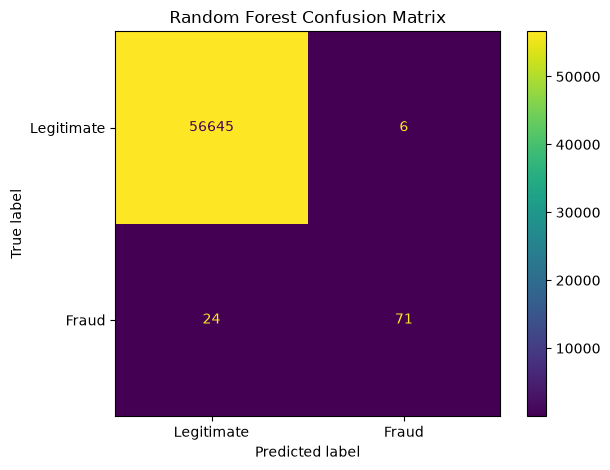

In [101]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_test_predictions,
    display_labels=["Legitimate", "Fraud"],
    values_format="d"
)

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

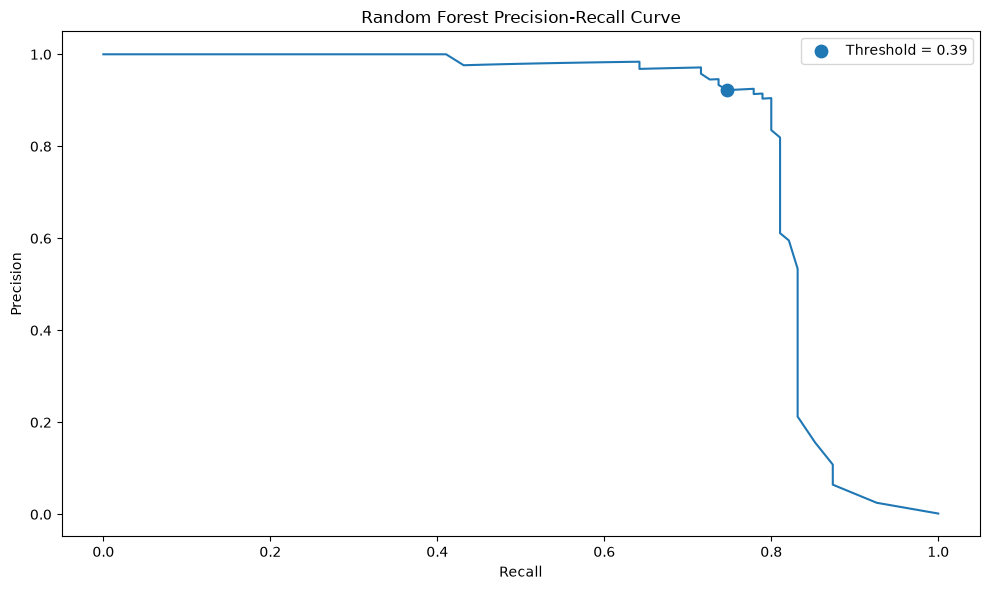

In [102]:
from sklearn.metrics import precision_recall_curve

precision_values, recall_values, thresholds = precision_recall_curve(
    y_test,
    rf_test_probabilities
)

plt.figure(figsize=(10, 6))

plt.plot(
    recall_values,
    precision_values
)

plt.scatter(
    recall_score(y_test, rf_test_predictions),
    precision_score(y_test, rf_test_predictions),
    s=80,
    label=f"Threshold = {final_rf_threshold}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest Precision-Recall Curve")
plt.legend()

plt.tight_layout()
plt.show()

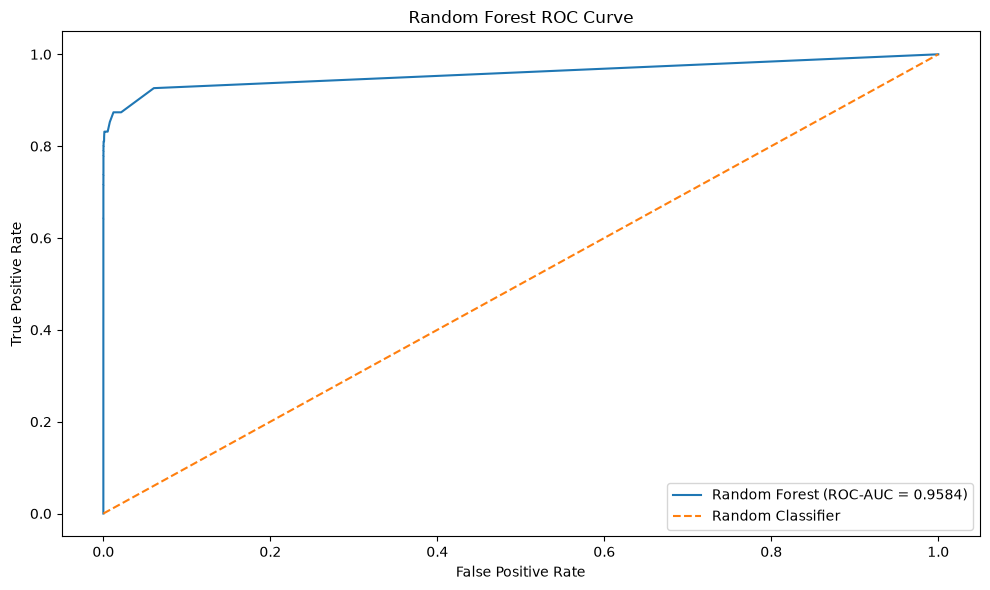

In [103]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_values, tpr_values, roc_thresholds = roc_curve(
    y_test,
    rf_test_probabilities
)

roc_auc = roc_auc_score(
    y_test,
    rf_test_probabilities
)

plt.figure(figsize=(10, 6))

plt.plot(
    fpr_values,
    tpr_values,
    label=f"Random Forest (ROC-AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()

plt.tight_layout()
plt.show()

In [104]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    random_forest_model,
    "../models/random_forest_fraud_model.pkl"
)

joblib.dump(
    final_rf_threshold,
    "../models/fraud_threshold.pkl"
)

print("Random Forest model saved successfully.")
print(f"Decision threshold saved: {final_rf_threshold}")

Random Forest model saved successfully.
Decision threshold saved: 0.39


In [105]:
import joblib
import pandas as pd

# Load saved model
loaded_model = joblib.load(
    "../models/random_forest_fraud_model.pkl"
)

# Load saved threshold
loaded_threshold = joblib.load(
    "../models/fraud_threshold.pkl"
)

print("Model loaded successfully.")
print(f"Threshold: {loaded_threshold}")

Model loaded successfully.
Threshold: 0.39


In [106]:
# Select one transaction from the test set
sample_transaction = X_test.iloc[[0]]

# Get fraud probability
sample_probability = loaded_model.predict_proba(
    sample_transaction
)[0, 1]

# Apply saved threshold
sample_prediction = int(
    sample_probability >= loaded_threshold
)

print("Transaction Prediction")
print("----------------------")
print(f"Fraud probability : {sample_probability:.4f}")
print(f"Threshold         : {loaded_threshold}")
print(
    f"Prediction        : "
    f"{'FRAUD' if sample_prediction == 1 else 'LEGITIMATE'}"
)

Transaction Prediction
----------------------
Fraud probability : 0.0000
Threshold         : 0.39
Prediction        : LEGITIMATE


In [107]:
# Find the first actual fraud transaction in the test set
fraud_index = y_test[y_test == 1].index[0]

fraud_transaction = X_test.loc[[fraud_index]]

# Get fraud probability
fraud_probability = loaded_model.predict_proba(
    fraud_transaction
)[0, 1]

# Apply saved threshold
fraud_prediction = int(
    fraud_probability >= loaded_threshold
)

print("Known Fraud Transaction Prediction")
print("-----------------------------------")
print(f"Actual class      : FRAUD")
print(f"Fraud probability : {fraud_probability:.4f}")
print(f"Threshold         : {loaded_threshold}")
print(
    f"Prediction        : "
    f"{'FRAUD' if fraud_prediction == 1 else 'LEGITIMATE'}"
)

Known Fraud Transaction Prediction
-----------------------------------
Actual class      : FRAUD
Fraud probability : 0.9100
Threshold         : 0.39
Prediction        : FRAUD


In [108]:
def predict_fraud(transaction):
    """
    Predict whether a transaction is fraudulent.

    Parameters:
        transaction: pandas DataFrame containing transaction features

    Returns:
        fraud_probability: probability of fraud
        prediction: 1 for fraud, 0 for legitimate
    """
    
    fraud_probability = loaded_model.predict_proba(
        transaction
    )[0, 1]
    
    prediction = int(
        fraud_probability >= loaded_threshold
    )
    
    return fraud_probability, prediction

In [109]:
fraud_probability, prediction = predict_fraud(
    fraud_transaction
)

print("Reusable Prediction Function")
print("----------------------------")
print(f"Fraud probability : {fraud_probability:.4f}")
print(f"Threshold         : {loaded_threshold}")
print(
    f"Prediction        : "
    f"{'FRAUD' if prediction == 1 else 'LEGITIMATE'}"
)

Reusable Prediction Function
----------------------------
Fraud probability : 0.9100
Threshold         : 0.39
Prediction        : FRAUD


In [110]:
import sys
import sklearn
import joblib

print("Python version:", sys.version)
print("scikit-learn version:", sklearn.__version__)
print("joblib version:", joblib.__version__)

Python version: 3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]
scikit-learn version: 1.9.1
joblib version: 1.6.0


In [112]:
rf_pr_auc = average_precision_score(
    y_test,
    rf_test_probabilities
)

print("Random Forest PR-AUC:", rf_pr_auc)

Random Forest PR-AUC: 0.8144955293168471


In [113]:
import joblib

saved_threshold = joblib.load(
    "../models/fraud_threshold.pkl"
)

print("Saved threshold:", saved_threshold)

Saved threshold: 0.39


In [114]:
import joblib

loaded_model = joblib.load(
    "../models/random_forest_fraud_model.pkl"
)

print("Saved Random Forest model loaded successfully.")
print("Number of trees:", loaded_model.n_estimators)

Saved Random Forest model loaded successfully.
Number of trees: 200
